# LOADING THE DATASET

In [1]:
import pandas as pd


df=pd.read_csv("energy_and_weather_dataset.csv")


print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(df.duplicated().sum())

# Display first few rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  object 
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196549 non-null  float64
 3   temp                    196560 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196549 non-null  float64
 6   wind_speed              196577 non-null  float64
 7   rain_1h                 196565 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type        

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100.0,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100.0,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100.0,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100.0,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100.0,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


# PREPROCESSING

In [2]:
# Convert "Time" to datetime format
df["Time"] = pd.to_datetime(df["Time"])

# Handling missing values
weather_cols = ["GHI", "temp", "humidity", "wind_speed", "rain_1h"]
df[weather_cols] = df[weather_cols].ffill()


# Fill remaining missing values (if any)
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)

# Convert "weather_type" to categorical
df["weather_type"] = df["weather_type"].astype("category")

# Check if preprocessing worked
print(df.info())
print(df.isnull().sum())  # Should print all zeros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Time                    196776 non-null  datetime64[ns]
 1   Energy delta[Wh]        196776 non-null  int64         
 2   GHI                     196776 non-null  float64       
 3   temp                    196776 non-null  float64       
 4   pressure                196776 non-null  int64         
 5   humidity                196776 non-null  float64       
 6   wind_speed              196776 non-null  float64       
 7   rain_1h                 196776 non-null  float64       
 8   snow_1h                 196776 non-null  float64       
 9   clouds_all              196776 non-null  int64         
 10  isSun                   196776 non-null  int64         
 11  sunlightTime            196776 non-null  int64         
 12  dayLength               196776

# EXPLORATORY DATA ANALYSIS

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


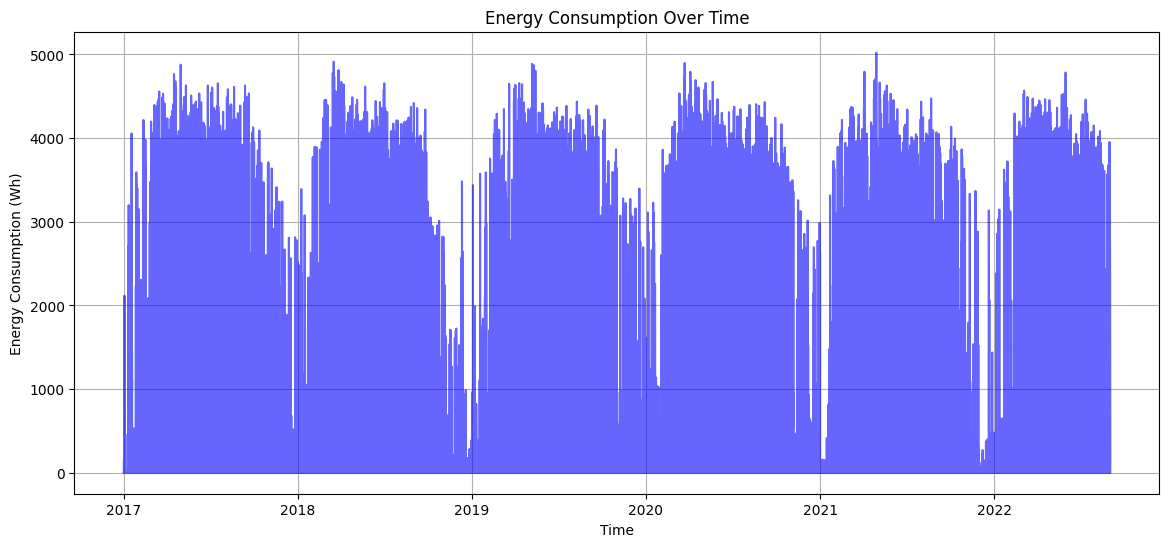

In [4]:
# Set 'Time' as index for time series visualization
df.set_index('Time', inplace=True)

# Plot Energy Consumption Over Time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Energy delta[Wh]'], color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Energy Consumption Over Time')
plt.grid()
plt.show()

## Insights from the Energy Consumption Over Time Plot:

- Seasonal Trends: There are clear yearly patterns, indicating that energy usage follows seasonal cycles.
- Spikes in Usage: Some periods show higher energy consumption, likely due to extreme weather conditions (summer cooling, winter heating).
- Dropouts in Data: Some periods show missing or significantly lower values, which may indicate sensor failures or system downtimes.

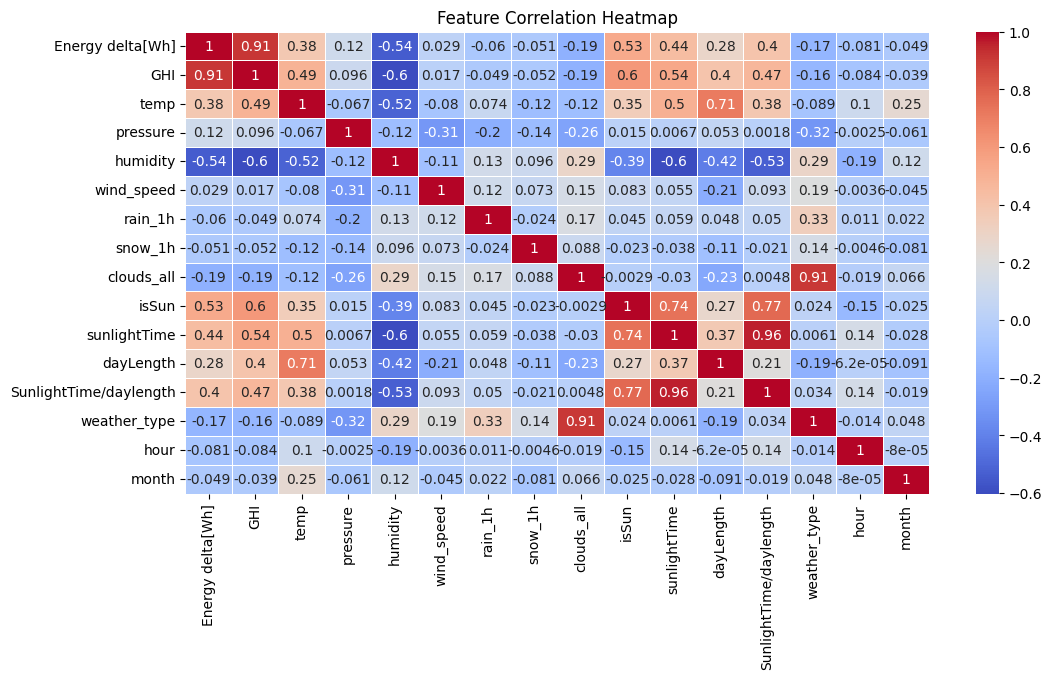

In [5]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## Insights from the Correlation Heatmap:

Strongest Correlation with Energy Consumption (Energy delta[Wh]):
  - Global Horizontal Irradiance (GHI): 0.91 correlation, meaning sunlight exposure has a strong influence on energy usage.
  - IsSun (daytime indicator): 0.53 correlation, suggesting more energy consumption during the day.
  - Sunlight Time & Day Length: Moderate correlation, meaning solar energy availability impacts energy demand.

Weather Factors with Lower Correlation:
  - Temperature (temp): 0.38 correlation—warmer weather might slightly reduce energy usage (less heating).
  - Humidity: Negative correlation (-0.54), meaning humid conditions may reduce energy demand.
  - Wind Speed & Rainfall: Weak or negligible correlation.

##Key Takeaway:

  - Sunlight and GHI are the most influential factors on energy consumption.
  - Weather conditions like rain and wind speed have minimal impact.

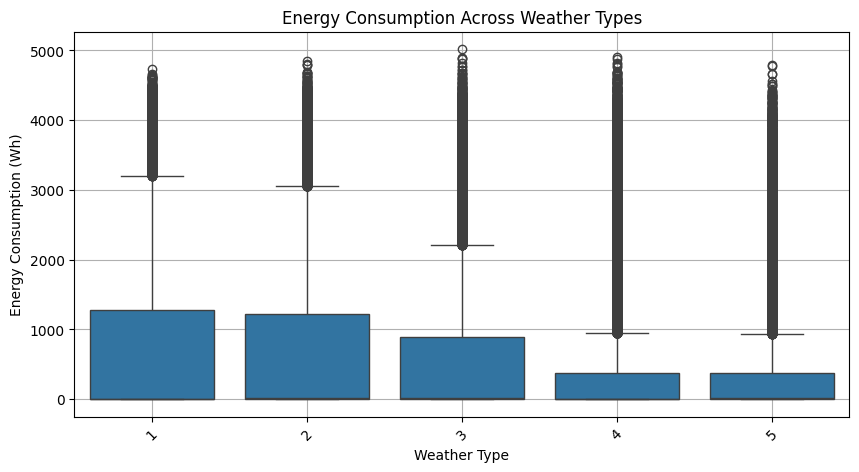

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='weather_type', y='Energy delta[Wh]', data=df)
plt.xlabel('Weather Type')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Energy Consumption Across Weather Types')
plt.xticks(rotation=45)
plt.grid()
plt.show()


## Insights from the Boxplot:

  - Higher Energy Consumption in Clear Weather: Weather types 1 and 2 show higher median energy consumption.
  - Lower Consumption in Cloudy/Rainy Weather: Weather types 4 and 5 show lower median consumption, likely due to reduced solar energy availability.
  - High Variability in All Weather Types: Outliers suggest energy spikes, possibly due to operational changes or weather anomalies.

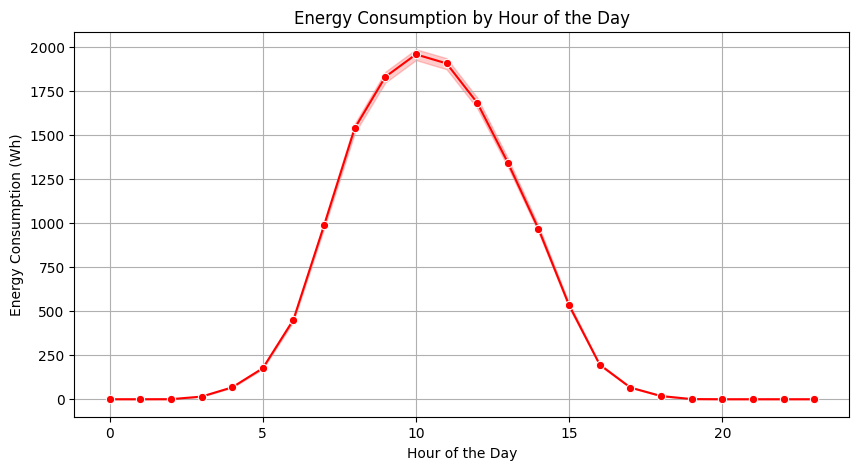

In [8]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='hour', y='Energy delta[Wh]', data=df, marker='o', color='red')
plt.xlabel('Hour of the Day')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Energy Consumption by Hour of the Day')
plt.grid()
plt.show()

## Insights from the Visualization:
1. Peak Energy Consumption:

  - There is a sharp rise in energy usage starting from around 6 AM.
  - The highest energy consumption occurs around 10-11 AM.
  - After noon, energy consumption starts to decline gradually.
2. Low Consumption Hours:

  - Energy consumption is lowest during midnight to early morning (12 AM - 5 AM).
  - There is a sharp drop in energy usage after 3-4 PM.
3. Daily Pattern:

  - The pattern suggests morning peaks, likely due to increased appliance usage, heating, and industrial activities.
  - Evening consumption is lower, possibly indicating energy-saving habits or reliance on natural lighting in the evening.

C:\Users\saina\AppData\Local\Temp\ipykernel_11864\1732778158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='Energy delta[Wh]', data=df, palette='coolwarm')


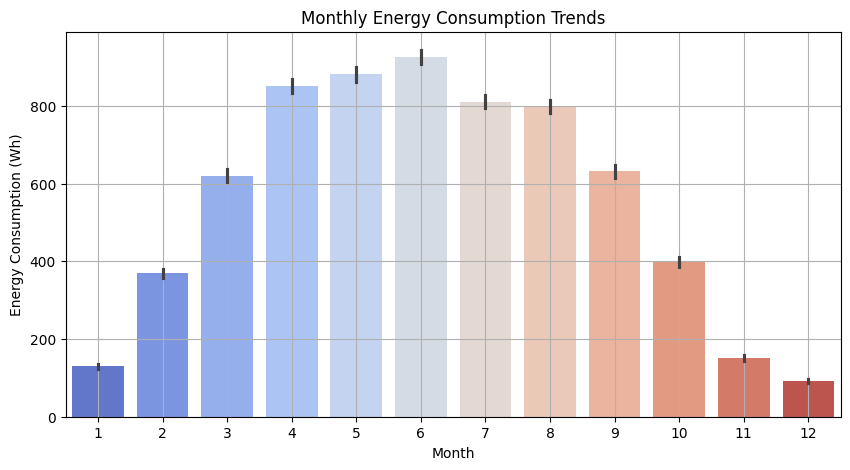

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='Energy delta[Wh]', data=df, palette='coolwarm')
plt.xlabel('Month')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Monthly Energy Consumption Trends')
plt.grid()
plt.show()

## Insights from the Monthly Energy Consumption Trends:
Peak Consumption in Mid-Year (April–August):

1. Energy consumption is highest between April and August, possibly due to increased cooling demand in summer.
2. Lower Consumption in Winter (December–February):

The lowest energy consumption occurs in December and January, likely because of reduced cooling needs and potentially lower overall energy demand.
3. Gradual Increase from February to June:

There is a steady rise in energy usage from February to June, which could be due to increasing temperatures.
4. Decline After August:

After August, energy consumption gradually declines, likely as temperatures drop and cooling needs reduce.

##Key Takeaways:

  - Summer months may contribute to higher energy consumption due to air conditioning usage.
  - Energy demand in winter is significantly lower, indicating seasonal variations in energy consumption.
  - Understanding these patterns can help in energy forecasting and resource planning.

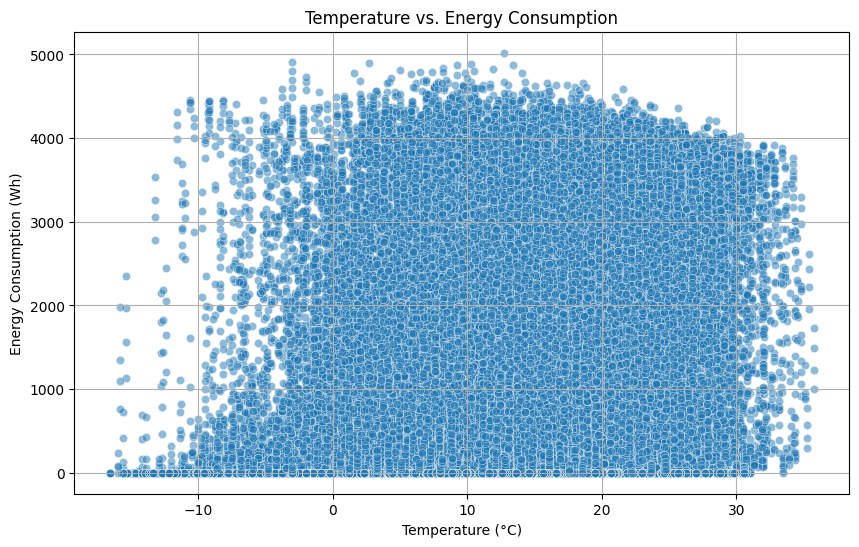

In [12]:
# Scatter plot: Temperature vs. Energy Consumption
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['temp'], y=df['Energy delta[Wh]'], alpha=0.5)
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Temperature vs. Energy Consumption')
plt.grid()
plt.show()

## Insights from Temperature vs. Energy Consumption:

1. No Strong Linear Relationship: Energy consumption is spread across all temperature ranges.

2. Slight U-Shaped Trend:
  - Higher energy usage in cold weather (below 0°C), likely due to heating needs.
  - Higher energy consumption in very hot weather (above 25°C), possibly due to air conditioning.

3. More Density in Moderate Temperatures (0°C to 20°C): Energy usage is relatively stable in this range.

In [6]:
df.isnull().sum()

Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64

# OUTLIER DETECTION


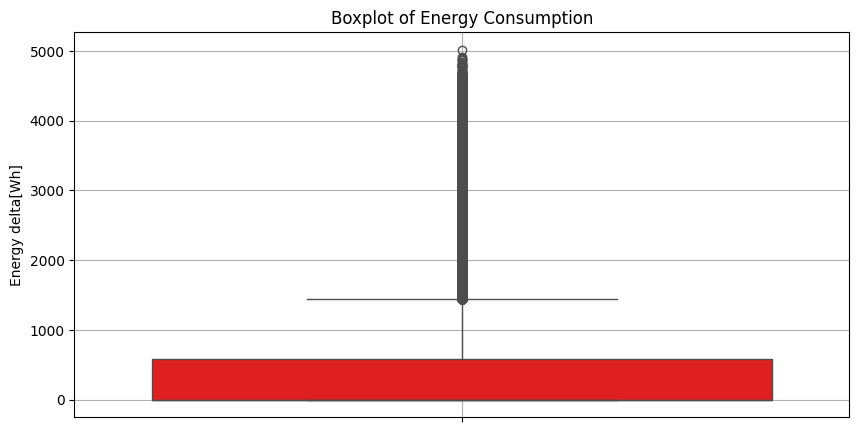

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(y=df["Energy delta[Wh]"], color="red")
plt.title("Boxplot of Energy Consumption")
plt.grid()
plt.show()

- Outliers:

There are many extreme values above 1000 Wh.
These points could be anomalies or rare high-consumption events.
- Distribution Shape:

Most data points fall below 1000 Wh, meaning regular energy usage is in this range.
The box (IQR range) is compressed, meaning most values are clustered within a smaller range.
- Possible Causes of Outliers:

High Demand Events – Industrial or commercial operations increasing usage.
Measurement Errors – Faulty sensors recording unrealistic spikes.
Unusual Weather Conditions – Extreme heat/cold increasing heating or cooling needs.


In [7]:

from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df["Energy delta[Wh]"]))
outliers = df[z_scores > 3]  # Get outlier rows

print(f"Number of outliers detected: {len(outliers)}")

Number of outliers detected: 5271


## Cap/Floor Outliers-Winsorization


In [8]:
print(df['Energy delta[Wh]'].describe())

count    196776.000000
mean        573.008228
std        1044.824047
min           0.000000
25%           0.000000
50%           0.000000
75%         577.000000
max        5020.000000
Name: Energy delta[Wh], dtype: float64


Replace extreme values with the 5th & 95th percentiles
Keeps the outliers but reduces their impact

In [9]:
from scipy.stats.mstats import winsorize

# Define Winsorization limits (capping at 1st & 99th percentile)
lower_cap = df["Energy delta[Wh]"].quantile(0.05)
upper_cap = df["Energy delta[Wh]"].quantile(0.95)

# Apply Winsorization (Capping outliers)
df["Energy delta[Wh]"] = np.clip(df["Energy delta[Wh]"], lower_cap, upper_cap)

# Check the new distribution
print(df["Energy delta[Wh]"].describe())


count    196776.000000
mean        549.414969
std         973.167898
min           0.000000
25%           0.000000
50%           0.000000
75%         577.000000
max        3294.000000
Name: Energy delta[Wh], dtype: float64


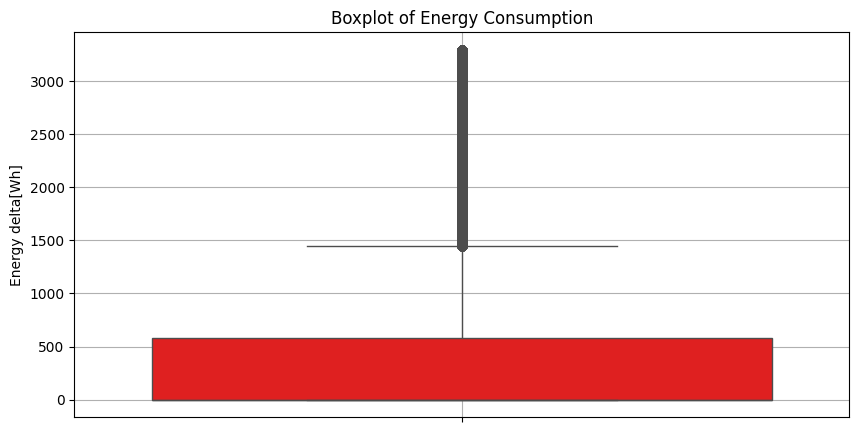

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(y=df["Energy delta[Wh]"], color="red")
plt.title("Boxplot of Energy Consumption")
plt.grid()
plt.show()

In [10]:

from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df["Energy delta[Wh]"]))
outliers = df[z_scores > 3]  # Get outlier rows

print(f"Number of outliers detected: {len(outliers)}")

Number of outliers detected: 0


# FEATURE ENGINEERING

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df.reset_index(inplace=True)  # Bring 'Time' back as a column


# TIME-BASED FEATURES (Essential for capturing periodic patterns)
df['hour'] = df['Time'].dt.hour                # Hour of the day (0-23)
df['day_of_week'] = df['Time'].dt.dayofweek    # Day of the week (0=Monday, 6=Sunday)
df['month'] = df['Time'].dt.month              # Month (1-12)
df['weekend'] = (df['day_of_week'] >= 5).astype(int)  # 1 if weekend, 0 if weekday
df['quarter'] = df['Time'].dt.quarter          # Quarter of the year (1-4)

# SEASON FEATURE (Useful for capturing seasonal variations)
def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    elif month in [3, 4, 5]: return "Spring"
    elif month in [6, 7, 8]: return "Summer"
    else: return "Autumn"

df['season'] = df['month'].apply(get_season)

# LAG FEATURES (Key for time-series forecasting)
df['lag_1h'] = df['Energy delta[Wh]'].shift(1)   # Previous hour’s consumption
df['lag_24h'] = df['Energy delta[Wh]'].shift(24) # Previous day's same hour consumption
df['lag_7d'] = df['Energy delta[Wh]'].shift(168) # Last week's same hour consumption

# ROLLING WINDOW FEATURES (Shorter windows to help capture trends)
df['rolling_mean_3h'] = df['Energy delta[Wh]'].rolling(window=3).mean()   # 3-hour moving avg
df['rolling_mean_24h'] = df['Energy delta[Wh]'].rolling(window=24).mean() # 24-hour moving avg

# INTERACTION FEATURES (Helps tree models capture dependencies)
df['temp_humidity_interaction'] = df['temp'] * df['humidity']
df['wind_temp_interaction'] = df['wind_speed'] * df['temp']

# LABEL ENCODING FOR CATEGORICAL FEATURES (Trees handle categorical data well)
le = LabelEncoder()
df["weather_type_encoded"] = le.fit_transform(df["weather_type"])
df["season_encoded"] = le.fit_transform(df["season"])

# DROPPING UNNECESSARY COLUMNS
df.drop(columns=['season', 'weather_type','Time'], inplace=True)

# Drop rows with NaNs to maintain clean features
df.dropna(inplace=True)



In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196608 entries, 168 to 196775
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Energy delta[Wh]           196608 non-null  int64  
 1   GHI                        196608 non-null  float64
 2   temp                       196608 non-null  float64
 3   pressure                   196608 non-null  int64  
 4   humidity                   196608 non-null  float64
 5   wind_speed                 196608 non-null  float64
 6   rain_1h                    196608 non-null  float64
 7   snow_1h                    196608 non-null  float64
 8   clouds_all                 196608 non-null  int64  
 9   isSun                      196608 non-null  int64  
 10  sunlightTime               196608 non-null  int64  
 11  dayLength                  196608 non-null  int64  
 12  SunlightTime/daylength     196608 non-null  float64
 13  hour                       19660

In [13]:
df.isnull().sum()

Energy delta[Wh]             0
GHI                          0
temp                         0
pressure                     0
humidity                     0
wind_speed                   0
rain_1h                      0
snow_1h                      0
clouds_all                   0
isSun                        0
sunlightTime                 0
dayLength                    0
SunlightTime/daylength       0
hour                         0
month                        0
day_of_week                  0
weekend                      0
quarter                      0
lag_1h                       0
lag_24h                      0
lag_7d                       0
rolling_mean_3h              0
rolling_mean_24h             0
temp_humidity_interaction    0
wind_temp_interaction        0
weather_type_encoded         0
season_encoded               0
dtype: int64

In [14]:
print(df)


        Energy delta[Wh]   GHI  temp  pressure  humidity  wind_speed  rain_1h  \
168                    0   0.0  -0.7      1015      87.0         4.4      0.0   
169                    0   0.0  -0.7      1015      87.0         4.4      0.0   
170                    0   0.0  -0.7      1015      87.0         4.4      0.0   
171                    0   0.0  -0.7      1015      87.0         4.4      0.0   
172                    0   0.0  -0.8      1016      89.0         4.3      0.0   
...                  ...   ...   ...       ...       ...         ...      ...   
196771               118  23.7  18.6      1023      57.0         3.8      0.0   
196772                82  15.6  18.5      1023      61.0         4.2      0.0   
196773                51   8.0  18.5      1023      61.0         4.2      0.0   
196774                24   2.1  18.5      1023      61.0         4.2      0.0   
196775                 0   0.0  18.5      1023      61.0         4.2      0.0   

        snow_1h  clouds_all

In [16]:
df.reset_index(drop=True, inplace=True)


In [17]:
print(df)


        Energy delta[Wh]   GHI  temp  pressure  humidity  wind_speed  rain_1h  \
0                      0   0.0  -0.7      1015      87.0         4.4      0.0   
1                      0   0.0  -0.7      1015      87.0         4.4      0.0   
2                      0   0.0  -0.7      1015      87.0         4.4      0.0   
3                      0   0.0  -0.7      1015      87.0         4.4      0.0   
4                      0   0.0  -0.8      1016      89.0         4.3      0.0   
...                  ...   ...   ...       ...       ...         ...      ...   
196603               118  23.7  18.6      1023      57.0         3.8      0.0   
196604                82  15.6  18.5      1023      61.0         4.2      0.0   
196605                51   8.0  18.5      1023      61.0         4.2      0.0   
196606                24   2.1  18.5      1023      61.0         4.2      0.0   
196607                 0   0.0  18.5      1023      61.0         4.2      0.0   

        snow_1h  clouds_all

# FEATURE SELECTION

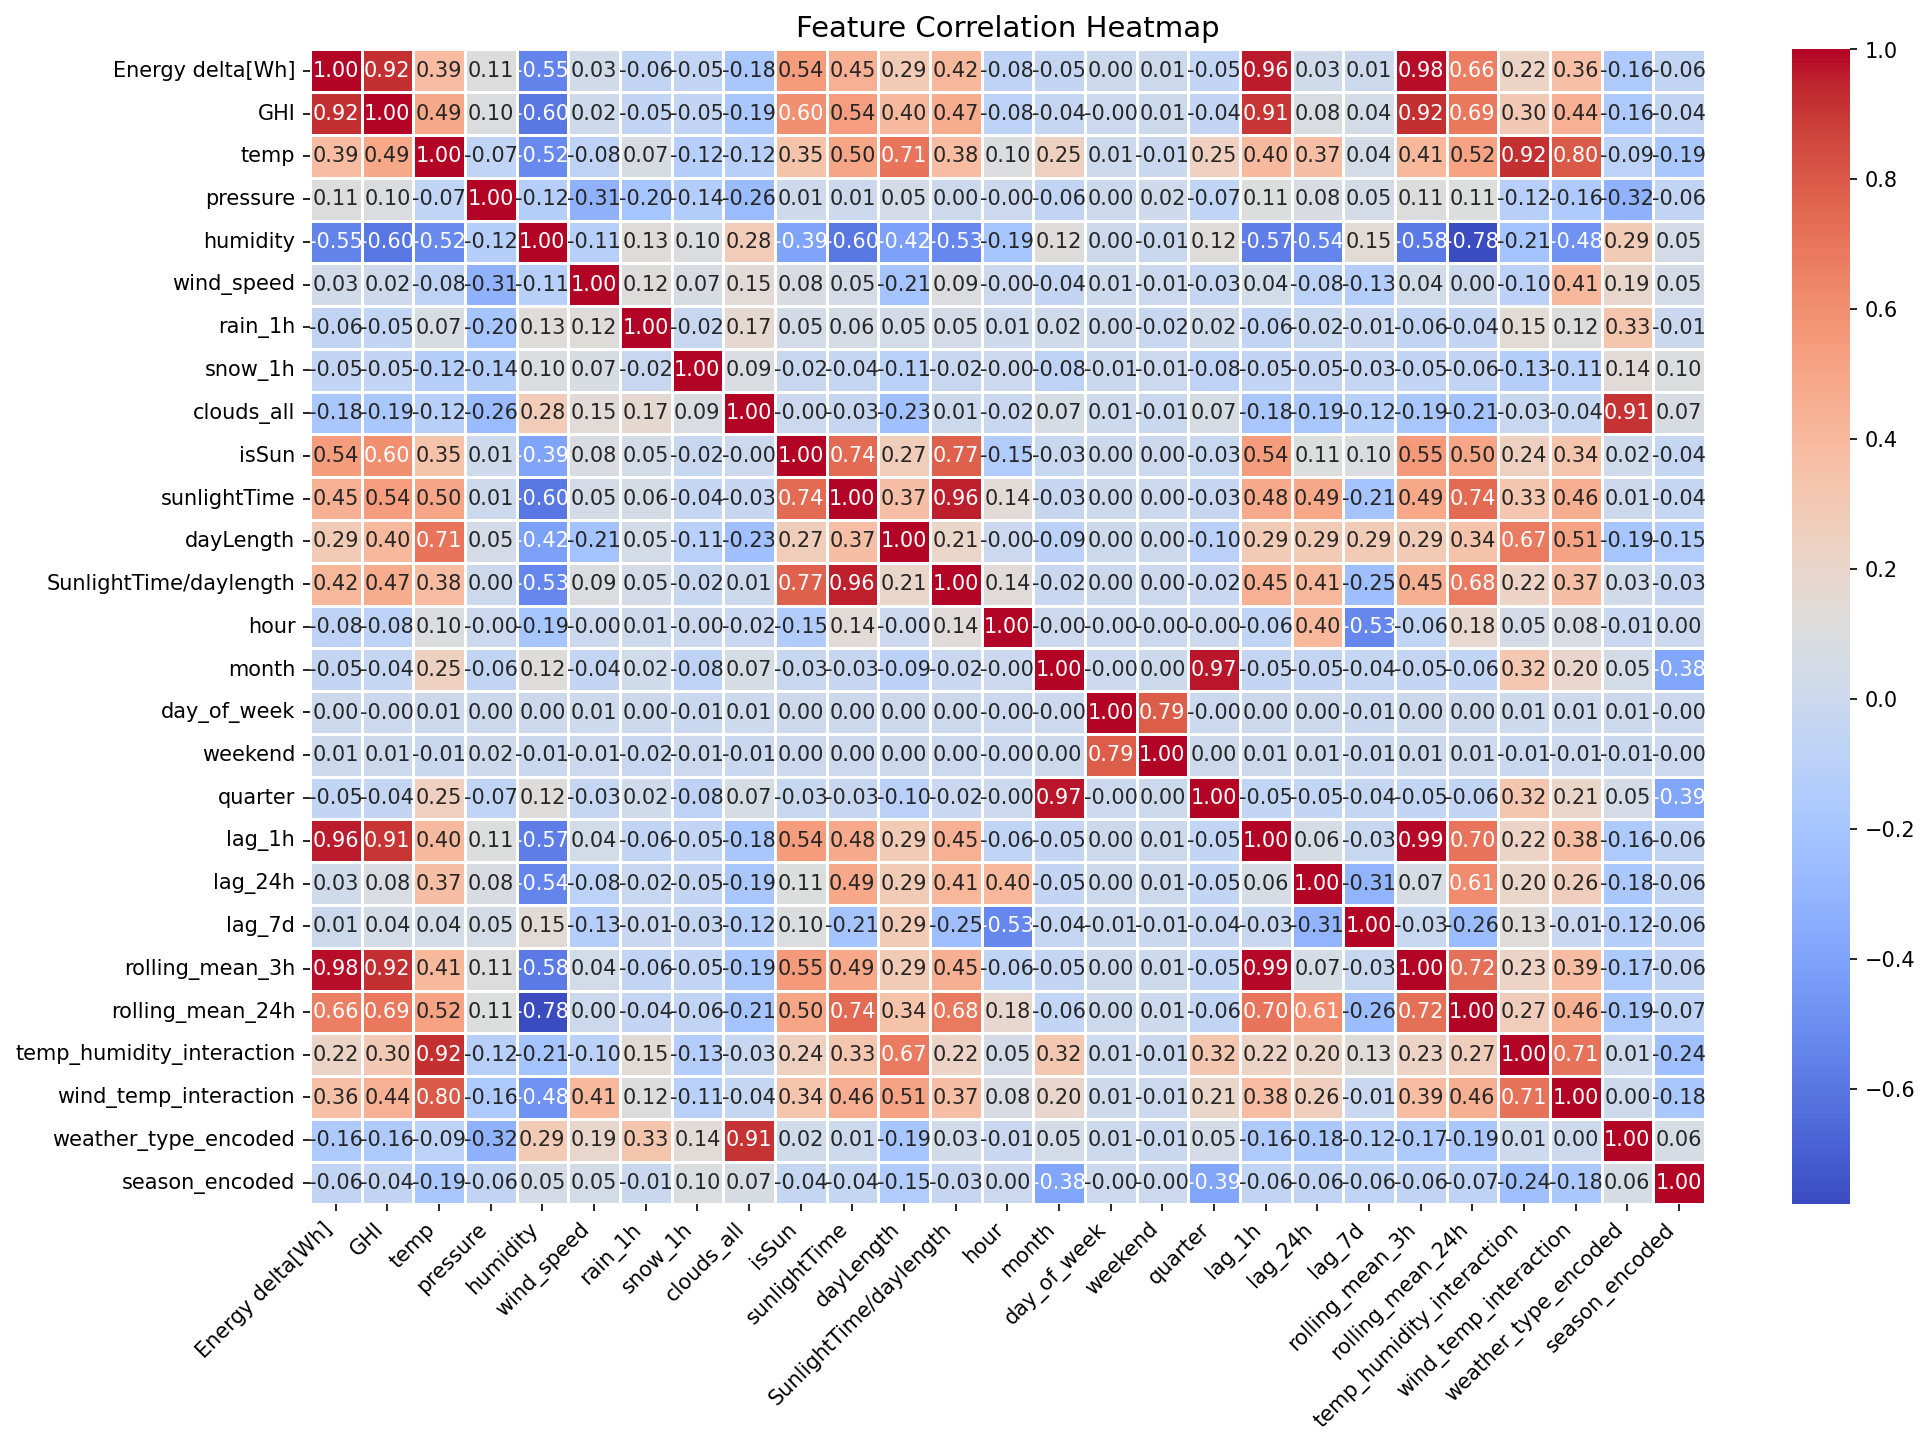

Highly Correlated Feature Pairs:
 lag_1h                     rolling_mean_3h              0.989612
rolling_mean_3h            lag_1h                       0.989612
                           Energy delta[Wh]             0.979286
Energy delta[Wh]           rolling_mean_3h              0.979286
quarter                    month                        0.970414
month                      quarter                      0.970414
Energy delta[Wh]           lag_1h                       0.958779
lag_1h                     Energy delta[Wh]             0.958779
sunlightTime               SunlightTime/daylength       0.958045
SunlightTime/daylength     sunlightTime                 0.958045
GHI                        rolling_mean_3h              0.923232
rolling_mean_3h            GHI                          0.923232
temp_humidity_interaction  temp                         0.921245
temp                       temp_humidity_interaction    0.921245
Energy delta[Wh]           GHI                          

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(15, 10), dpi=150)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


# Identify highly correlated features
high_corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs != 1]  # Remove self-correlation

# Filter pairs with correlation > 0.85
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.85]
print("Highly Correlated Feature Pairs:\n", high_corr_pairs)


Based on correlation, we have to drop:

- rolling_mean_3h (since it's highly correlated with lag_1h and Energy delta[Wh])
- quarter (since it's highly correlated with month)
- sunlightTime (since it's highly correlated with SunlightTime/daylength)
- temp_humidity_interaction (since it's highly correlated with temp)
- weather_type_encoded (since it's highly correlated with clouds_all)

In [19]:
features_to_drop = [
    "rolling_mean_3h",
    "quarter",
    "sunlightTime",
    "temp_humidity_interaction",
    "weather_type_encoded"
]

df_selected = df.drop(columns=features_to_drop)
print("Dropped Features:", features_to_drop)


Dropped Features: ['rolling_mean_3h', 'quarter', 'sunlightTime', 'temp_humidity_interaction', 'weather_type_encoded']


## VIF FOR FEATURE SELECTION

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Define X (features only, excluding target variable)
X = df_selected.drop(columns=["Energy delta[Wh]"])  # Ensure target is not included

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort VIF values
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("Variance Inflation Factor (VIF):\n", vif_data)



Variance Inflation Factor (VIF):
                    Feature         VIF
2                 pressure  212.050835
3                 humidity   90.735545
9                dayLength   50.654427
1                     temp   20.275092
4               wind_speed   17.071783
19   wind_temp_interaction   16.597286
18        rolling_mean_24h   11.864726
0                      GHI   11.030447
15                  lag_1h    9.862459
8                    isSun    9.168159
13             day_of_week    8.669462
10  SunlightTime/daylength    8.344919
12                   month    7.527711
11                    hour    6.194015
7               clouds_all    5.295607
16                 lag_24h    4.538370
20          season_encoded    3.793850
14                 weekend    3.745186
17                  lag_7d    2.690619
5                  rain_1h    1.184915
6                  snow_1h    1.065525


In [21]:
features_to_drop_vif = ["pressure", "humidity", "dayLength"]  # Start with these

df_selected_vif = df_selected.drop(columns=features_to_drop_vif)

# Recalculate VIF
X_vif = df_selected_vif.drop(columns=["Energy delta[Wh]"])
vif_data_new = pd.DataFrame()
vif_data_new["Feature"] = X_vif.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort VIF values
vif_data_new = vif_data_new.sort_values(by="VIF", ascending=False)

print("Updated VIF after removing high-correlation features:\n", vif_data_new)


Updated VIF after removing high-correlation features:
                    Feature        VIF
1                     temp  15.140831
16   wind_temp_interaction  13.782385
2               wind_speed  11.192621
15        rolling_mean_24h  10.883671
0                      GHI  10.591645
12                  lag_1h   9.756947
6                    isSun   9.004566
7   SunlightTime/daylength   8.227138
10             day_of_week   8.103616
8                     hour   5.002622
9                    month   4.854991
5               clouds_all   4.658197
13                 lag_24h   4.335062
11                 weekend   3.677900
17          season_encoded   3.217517
14                  lag_7d   2.082666
3                  rain_1h   1.126352
4                  snow_1h   1.052559


In [22]:
# Drop the highest VIF feature first
features_to_drop_vif = ["wind_temp_interaction"]  # Adjust step-by-step
df_selected_vif = df_selected_vif.drop(columns=features_to_drop_vif)

# Recalculate VIF
X_vif = df_selected_vif.drop(columns=["Energy delta[Wh]"])  # Assuming this is the target variable
vif_data_new = pd.DataFrame()
vif_data_new["Feature"] = X_vif.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort VIF values
vif_data_new = vif_data_new.sort_values(by="VIF", ascending=False)

print("Updated VIF after removing high-VIF features:\n", vif_data_new)


Updated VIF after removing high-VIF features:
                    Feature        VIF
15        rolling_mean_24h  10.879669
0                      GHI  10.577358
12                  lag_1h   9.741428
6                    isSun   8.979332
7   SunlightTime/daylength   8.220426
10             day_of_week   7.987435
2               wind_speed   5.148297
1                     temp   4.881854
8                     hour   4.801567
9                    month   4.632483
5               clouds_all   4.580504
13                 lag_24h   4.316783
11                 weekend   3.661879
16          season_encoded   2.935592
14                  lag_7d   2.025353
3                  rain_1h   1.125526
4                  snow_1h   1.043927


In [23]:
# Drop the highest VIF feature first
features_to_drop_vif = ["rolling_mean_24h"]  
df_selected_vif = df_selected_vif.drop(columns=features_to_drop_vif)

# Recalculate VIF
X_vif = df_selected_vif.drop(columns=["Energy delta[Wh]"])  # Assuming this is the target variable
vif_data_new = pd.DataFrame()
vif_data_new["Feature"] = X_vif.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort VIF values
vif_data_new = vif_data_new.sort_values(by="VIF", ascending=False)

print("Updated VIF after removing rolling_mean_24h:\n", vif_data_new)


Updated VIF after removing rolling_mean_24h:
                    Feature        VIF
0                      GHI  10.187145
6                    isSun   8.645356
12                  lag_1h   8.012356
10             day_of_week   7.985034
7   SunlightTime/daylength   6.984137
2               wind_speed   5.138311
1                     temp   4.859012
8                     hour   4.748887
9                    month   4.631223
5               clouds_all   4.577821
11                 weekend   3.661644
15          season_encoded   2.935592
13                 lag_24h   2.363025
14                  lag_7d   2.003347
3                  rain_1h   1.124501
4                  snow_1h   1.043845


In [24]:
# Drop the highest VIF feature first
features_to_drop_vif = ["GHI"]  
df_selected_vif = df_selected_vif.drop(columns=features_to_drop_vif)

# Recalculate VIF
X_vif = df_selected_vif.drop(columns=["Energy delta[Wh]"])  # Assuming this is the target variable
vif_data_new = pd.DataFrame()
vif_data_new["Feature"] = X_vif.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Sort VIF values
vif_data_new = vif_data_new.sort_values(by="VIF", ascending=False)

print("Updated VIF after removing GHI:\n", vif_data_new)


Updated VIF after removing GHI:
                    Feature       VIF
5                    isSun  8.256148
9              day_of_week  7.980729
6   SunlightTime/daylength  6.960805
1               wind_speed  5.136209
7                     hour  4.746563
8                    month  4.592857
4               clouds_all  4.549648
0                     temp  4.376979
10                 weekend  3.660374
14          season_encoded  2.924116
12                 lag_24h  2.357211
11                  lag_1h  2.256156
13                  lag_7d  2.001914
2                  rain_1h  1.123036
3                  snow_1h  1.043321


In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Step 1: Define Your Final Feature Set (After VIF & Correlation Analysis)
selected_features = [
    "temp", "wind_speed", "hour", "month", "clouds_all", "weekend", "day_of_week",
    "SunlightTime/daylength", "season_encoded", "lag_24h", "lag_1h", "lag_7d", 
    "rain_1h", "snow_1h", "isSun"
]

# Step 2: Split Data into Training & Testing
X = df[selected_features]  # Select only final features
y = df["Energy delta[Wh]"]  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train a Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  

# Step 4: Get Feature Importance
importances = model.feature_importances_
feature_importance = pd.DataFrame({"Feature": selected_features, "Importance": importances})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Step 5: Display Top Features
print("\n Feature Importance (Sorted):\n")
print(feature_importance)




 Feature Importance (Sorted):

                   Feature    Importance
10                  lag_1h  9.297403e-01
7   SunlightTime/daylength  1.505812e-02
4               clouds_all  1.000678e-02
0                     temp  9.323813e-03
1               wind_speed  9.241866e-03
9                  lag_24h  6.643615e-03
11                  lag_7d  6.122117e-03
6              day_of_week  3.632100e-03
3                    month  3.408762e-03
12                 rain_1h  3.150119e-03
2                     hour  1.930565e-03
8           season_encoded  1.086087e-03
5                  weekend  5.310458e-04
13                 snow_1h  1.242697e-04
14                   isSun  3.952508e-07


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 6: Predict on Test Data
y_pred = model.predict(X_test)

# Step 7: Evaluate Model Performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n Model Evaluation:\n")
print(f" R² Score: {r2:.4f}")
print(f" RMSE: {rmse:.4f}")



 Model Evaluation:

 R² Score: 0.9338
 RMSE: 250.0033


In [27]:
# Select top features based on importance threshold
top_features = feature_importance[feature_importance["Importance"] > 0.005]["Feature"].tolist()
print("\n Selected Features for Final Model:\n", top_features)

# Update dataset with selected features
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Retrain model with fewer features
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_selected, y_train)

# Check performance with fewer features
print("\n Model trained with reduced features!")



 Selected Features for Final Model:
 ['lag_1h', 'SunlightTime/daylength', 'clouds_all', 'temp', 'wind_speed', 'lag_24h', 'lag_7d']

 Model trained with reduced features!


In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 6: Predict on Test Data (After Feature Selection)
y_pred_selected = model.predict(X_test_selected)

# Step 7: Evaluate Model Performance
r2_selected = r2_score(y_test, y_pred_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))

print(f"\n Model Evaluation (After Feature Selection):\n")
print(f" R² Score: {r2_selected:.4f}")
print(f" RMSE: {rmse_selected:.4f}")



 Model Evaluation (After Feature Selection):

 R² Score: 0.9332
 RMSE: 251.2365


Conclusion: Keep the Reduced Feature Set!

The R² score dropped very slightly (0.0006), which is insignificant—the model still explains ~93.3% of the variance in energy consumption.
The RMSE increased by only ~1.23, which is also a small trade-off considering that the model is now simpler and more efficient with fewer features.
Since performance is almost the same, keeping the reduced feature set is a good choice, especially since I'm planning to deploy the model in a web app (fewer features mean faster and lighter predictions).

In [36]:
# Step 1: Select the top 5 features
top_5_features = ["lag_1h", "SunlightTime/daylength", "clouds_all", "temp", "wind_speed"]

# Step 2: Filter the dataset
X_train_reduced = X_train[top_5_features]
X_test_reduced = X_test[top_5_features]

# Step 3: Train the model with reduced features
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_reduced, y_train)

# Step 4: Evaluate model performance
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test_reduced)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n Selected Features: {top_5_features}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")




 Selected Features: ['lag_1h', 'SunlightTime/daylength', 'clouds_all', 'temp', 'wind_speed']
R² Score: 0.9316
RMSE: 254.1245


### Key Insights
The R² score dropped only 0.0022 — this is minimal and acceptable.
The RMSE increased slightly by ~4.1 units — still within a reasonable range.
Given the reduced complexity (from 15 features to 5), this trade-off is justifiable for deployment in a web application.
### Final Decision: Are These 5 Features Good Enough?
Yes! The model shows minimal performance loss, meaning these 5 features effectively capture most of the predictive power.

# MODEL TRAINING

In [41]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Step 1: Define the Final 5 Features
selected_features = ['lag_1h', 'SunlightTime/daylength', 'clouds_all', 'temp', 'wind_speed']

# Step 2: Split Data into Training & Testing
X = df[selected_features]  # Select only final features
y = df["Energy delta[Wh]"]  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Step 4: Train LightGBM Model
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)

# Step 5: Model Evaluation
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

print("\nXGBoost Evaluation:")
print("R² Score:", r2_score(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("\nLightGBM Evaluation:")
print("R² Score:", r2_score(y_test, lgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 847
[LightGBM] [Info] Number of data points in the train set: 157286, number of used features: 5
[LightGBM] [Info] Start training from score 550.631035

XGBoost Evaluation:
R² Score: 0.93350750207901
RMSE: 250.5671145746185

LightGBM Evaluation:
R² Score: 0.9358285911022745
RMSE: 246.1549243560122


### COMPARISON

| Model         | Features Used | R² Score | RMSE  |
|----------------|----------------|-----------|--------|
| Random Forest   | 7 Features      | 0.9362    | 245.45 |
| Random Forest   | 5 Features      | 0.9316    | 254.12 |
| XGBoost         | 5 Features      | 0.9335    | 250.57 |
| LightGBM        | 5 Features      | 0.9358    | 246.15 |


### Conclusion & Next Steps
- LightGBM with 5 features performs almost as well as the 7-feature Random Forest model, with a slight increase in RMSE but minimal R² drop.

- Since the goal is to reduce features for deployment while maintaining performance, LightGBM with 5 features is the most balanced choice.

## Hypertune the LightGBM Model

In [27]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

# Step 1: Filter dataset to include the top 5 features
top_5_features = ["lag_1h", "SunlightTime/daylength", "clouds_all", "temp", "wind_speed"]
X_train_reduced = X_train[top_5_features]
X_test_reduced = X_test[top_5_features]

# Step 2: Define the LightGBM model
lgbm_model = LGBMRegressor(random_state=42)

# Step 3: Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Step 4: Perform Grid Search
grid_search = GridSearchCV(
    lgbm_model, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2
)
grid_search.fit(X_train_reduced, y_train)

# Step 5: Evaluate the Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_reduced)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n Best Parameters: {grid_search.best_params_}")
print(f"R² Score (Tuned LightGBM): {r2:.4f}")
print(f"RMSE (Tuned LightGBM): {rmse:.4f}")


Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 847
[LightGBM] [Info] Number of data points in the train set: 157286, number of used features: 5
[LightGBM] [Info] Start training from score 550.631035

 Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_samples': 30, 'n_estimators': 200, 'num_leaves': 20, 'subsample': 0.7}
R² Score (Tuned LightGBM): 0.9359
RMSE (Tuned LightGBM): 246.0906


In [30]:
# Evaluate on Training Data
y_train_pred = best_model.predict(X_train_reduced)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Evaluate on Test Data
y_test_pred = best_model.predict(X_test_reduced)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Display Results
print("\n📊 Overfitting Test Results:")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")



📊 Overfitting Test Results:
Training R² Score: 0.9358
Training RMSE: 246.8099
Test R² Score: 0.9359
Test RMSE: 246.0906


The model is not overfitting and is performing consistently well on both the training and test sets.

In [31]:
import joblib
# Save the model as a .pkl file
joblib.dump(best_model, "final_lightgbm_model.pkl")


['final_lightgbm_model.pkl']

## Distribution of Residuals (Errors)


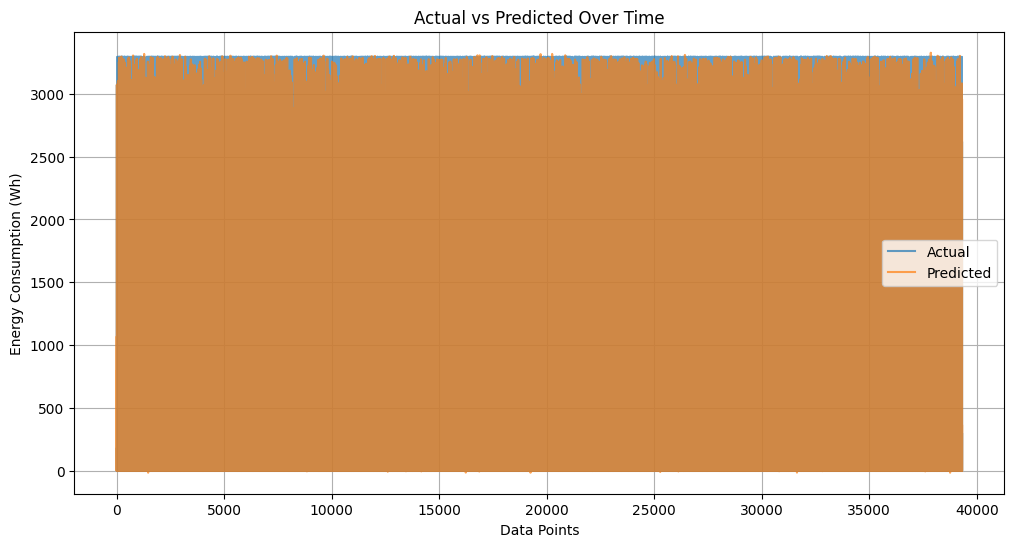

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(results['Actual'].values, label='Actual', alpha=0.7)
plt.plot(results['Predicted'].values, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Over Time")
plt.xlabel("Data Points")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()
plt.grid(True)
plt.show()


### Key Observations:
Strong Overlap:

- The predicted values closely follow the actual values, indicating that the model generalizes well.
- No major deviation patterns are visible, which is a positive sign for model stability.

Minor Fluctuations:

- The slight gaps and spikes in the blue line (Actual) are normal in time series data, especially when environmental factors (like weather) create unexpected shifts.
- These variations appear minimal, suggesting the model effectively captures most patterns.

## Actual vs Predicted Over Time

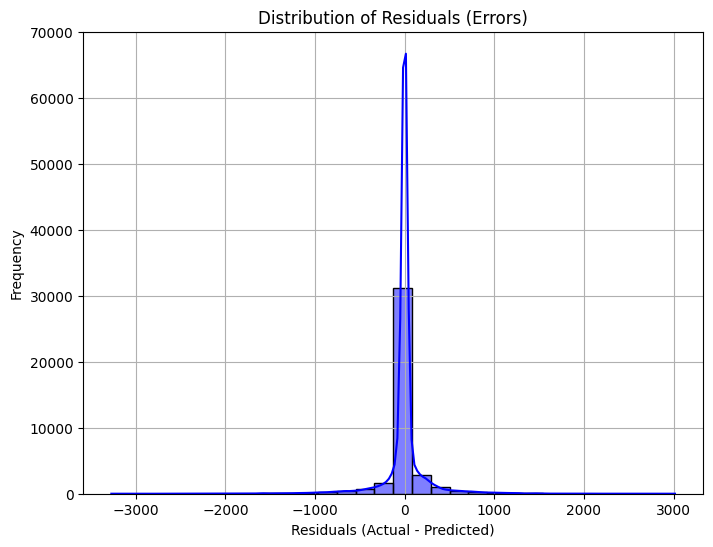

In [36]:
# Calculate residuals (Actual - Predicted)
residuals = y_test - y_test_pred

# Plot the distribution of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()



### Key Observations:
- Low Error Variability: Most predictions are close to the actual values.
- Minimal Bias: The plot is symmetric, suggesting no systematic over- or under-prediction.